# CSCI 347 — Data Mining | Final Project — Part 2
**Lucas Jones, John Nelson, and Henry Stickling**

**Dataset:** [Chicago Crimes 2012–2017 (Kaggle)](https://www.kaggle.com/datasets/currie32/crimes-in-chicago)

**Project Overview**
1. Load Dataset
2. Preprocessing 
3. K-Means Clustering (with K-Fold evaluation)
4. DBSCAN Clustering (with K-Fold evaluation)
5. Use K-fold evaluations to Compare Clustering Algorithms
6. Predictive Modeling — Random Forest to Predict High Risk Crime Zones
7. Crime Trend Vizualiations

---

## Imports & Setup

In [1]:
import kagglehub
import pandas as pd

path = kagglehub.dataset_download("currie32/crimes-in-chicago")

df = pd.read_csv(
    f"{path}/Chicago_Crimes_2012_to_2017.csv",
    encoding="latin-1",
    on_bad_lines="skip",
    engine="python"
)

print(f"Loaded {len(df):,} rows, {df.shape[1]} columns")

c:\Users\jones\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded 1,456,714 rows, 23 columns


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.metrics import silhouette_score, classification_report

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.family': 'sans-serif'
})

---
## 1. Data Loading & Initial Inspection

In [3]:
print('All columns:')
print(df.columns.tolist())

All columns:
['Unnamed: 0', 'ID', 'Case Number', 'Date', 'Block', 'IUCR', 'Primary Type', 'Description', 'Location Description', 'Arrest', 'Domestic', 'Beat', 'District', 'Ward', 'Community Area', 'FBI Code', 'X Coordinate', 'Y Coordinate', 'Year', 'Updated On', 'Latitude', 'Longitude', 'Location']


---
## 2. Preprocessing

### 2a. Drop Columns Irrelevant to Patrol Placement
Per professor feedback: `ID`, `Case Number`, `IUCR`, `FBI Code`, `Updated On`, and `Block` are identifiers or administrative fields that do not contribute to spatial or temporal crime analysis.

In [4]:
COLS_TO_DROP = ['ID', 'Case Number', 'IUCR', 'FBI Code', 'Updated On', 'Block', 'X Coordinate', 'Y Coordinate']
cols_present = [c for c in COLS_TO_DROP if c in df.columns]
df.drop(columns=cols_present, inplace=True)
print(f'Dropped {len(cols_present)} columns: {cols_present}')
print(f'Remaining columns ({df.shape[1]}): {df.columns.tolist()}')

Dropped 8 columns: ['ID', 'Case Number', 'IUCR', 'FBI Code', 'Updated On', 'Block', 'X Coordinate', 'Y Coordinate']
Remaining columns (15): ['Unnamed: 0', 'Date', 'Primary Type', 'Description', 'Location Description', 'Arrest', 'Domestic', 'Beat', 'District', 'Ward', 'Community Area', 'Year', 'Latitude', 'Longitude', 'Location']


### 2b. Drop Rows Without Geographic Coordinates
Crimes without lat/lon cannot be used for spatial analysis and cannot be meaningfully imputed.

In [5]:
LAT_MIN, LAT_MAX = 41.60, 42.05
LON_MIN, LON_MAX = -87.95, -87.50

df = df[
    (df['Latitude']  >= LAT_MIN) & (df['Latitude']  <= LAT_MAX) &
    (df['Longitude'] >= LON_MIN) & (df['Longitude'] <= LON_MAX)
].copy()

### 2c. Impute Remaining Missing Categoricals

In [6]:
cat_cols = ['Location Description', 'Ward', 'Community Area', 'District', 'Beat']
for col in cat_cols:
    if col in df.columns and df[col].isnull().sum() > 0:
        df[col] = df[col].astype(object).fillna('Unknown')

# Missing value summary after imputation
missing = df.isnull().sum()


### 2d. Parse Datetime Features

In [8]:
df['Date']      = pd.to_datetime(df['Date'], errors='coerce')
df['Hour']      = df['Date'].dt.hour
df['DayOfWeek'] = df['Date'].dt.dayofweek   # 0=Monday, 6=Sunday
df['Month']     = df['Date'].dt.month
df['IsWeekend'] = (df['DayOfWeek'] >= 5).astype(int)

df[['Hour', 'DayOfWeek', 'Month', 'IsWeekend']].head()

,Hour,DayOfWeek,Month,IsWeekend
0,23,1,5,0
1,21,1,5,0
2,23,1,5,0
3,22,1,5,0
4,22,1,5,0


### 2e. Encode Boolean & Categorical Columns

In [9]:
# Binary encode Arrest and Domestic
for bool_col in ['Arrest', 'Domestic']:
    if bool_col in df.columns and df[bool_col].dtype == object:
        df[bool_col] = df[bool_col].map({'true': 1, 'false': 0, True: 1, False: 0})

# Ensure Beat and District are numeric
for col in ['Beat', 'District']:
    if col in df.columns and df[col].dtype == object:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# Consolidate to top 10 crime groups + OTHER (bucket for all other crimes)
TOP_N = 10
top_crimes = df['Primary Type'].value_counts().nlargest(TOP_N).index.tolist()
df['CrimeGroup'] = df['Primary Type'].apply(lambda x: x if x in top_crimes else 'OTHER')

print(f'Final shape after preprocessing: {df.shape}')
print(f'\nCrimeGroup distribution:')
print(df['CrimeGroup'].value_counts())

Final shape after preprocessing: (1419554, 20)

CrimeGroup distribution:
CrimeGroup
THEFT                  322423
BATTERY                258929
CRIMINAL DAMAGE        152811
NARCOTICS              131173
OTHER                  113387
ASSAULT                 89507
OTHER OFFENSE           85356
BURGLARY                81671
DECEPTIVE PRACTICE      68352
MOTOR VEHICLE THEFT     59852
ROBBERY                 56093
Name: count, dtype: int64


### 2f. Sample for Computational Efficiency

In [10]:
SAMPLE_SIZE = 100_000
df_sample = df.sample(n=min(SAMPLE_SIZE, len(df)), random_state=RANDOM_STATE)
print(f'Working sample size: {len(df_sample):,}')

Working sample size: 100,000


---
## 3. Spatial Clustering — K-Means with K-Fold Evaluation

We use K-Fold cross-validation to get a stable, unbiased silhouette score for each candidate `k`. Each fold trains K-Means on a training split and scores on the held-out fold, then we average across folds. This addresses the professor's feedback to use K-Fold when comparing clustering algorithms.

We search `k` from 10 to 30 — reflecting that Chicago has 22 police districts and far more than 2 patrol zones.

In [11]:
SPATIAL_FEATURES = ['Latitude', 'Longitude']
coords = df_sample[SPATIAL_FEATURES].dropna().values
scaler_spatial = StandardScaler()
coords_scaled = scaler_spatial.fit_transform(coords)

N_SPLITS = 5
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
K_RANGE = range(10, 31)   # 10–30 patrol zones

km_cv_scores = {}  # k -> list of per-fold silhouette scores
km_inertias = {}

print(f'K-Means K-Fold CV (k=10..30, {N_SPLITS} folds):')
for k in K_RANGE:
    fold_sils = []
    fold_inertias = []
    for train_idx, test_idx in kf.split(coords_scaled):
        X_tr = coords_scaled[train_idx]
        X_te = coords_scaled[test_idx]
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        km.fit(X_tr)
        labels_te = km.predict(X_te)
        if len(set(labels_te)) > 1:
            sil = silhouette_score(X_te, labels_te, sample_size=min(5000, len(X_te)), random_state=RANDOM_STATE)
            fold_sils.append(sil)
        fold_inertias.append(km.inertia_)
    km_cv_scores[k] = fold_sils
    km_inertias[k] = np.mean(fold_inertias)
    mean_sil = np.mean(fold_sils)
    std_sil = np.std(fold_sils)
    print(f'  k={k:2d} | mean_sil={mean_sil:.4f} ± {std_sil:.4f} | mean_inertia={km_inertias[k]:>12,.0f}')

mean_sils = {k: np.mean(v) for k, v in km_cv_scores.items()}
best_k = max(mean_sils, key=mean_sils.get)
print(f'\nBest k by CV silhouette: {best_k}  (score={mean_sils[best_k]:.4f})')

K-Means K-Fold CV (k=10..30, 5 folds):
  k=10 | mean_sil=0.4132 ± 0.0013 | mean_inertia=      14,005
  k=11 | mean_sil=0.4081 ± 0.0014 | mean_inertia=      12,786
  k=12 | mean_sil=0.4054 ± 0.0033 | mean_inertia=      11,658
  k=13 | mean_sil=0.4021 ± 0.0022 | mean_inertia=      10,656
  k=14 | mean_sil=0.3960 ± 0.0042 | mean_inertia=       9,827
  k=15 | mean_sil=0.3959 ± 0.0034 | mean_inertia=       8,992
  k=16 | mean_sil=0.4008 ± 0.0018 | mean_inertia=       8,257
  k=17 | mean_sil=0.3979 ± 0.0018 | mean_inertia=       7,764
  k=18 | mean_sil=0.3982 ± 0.0045 | mean_inertia=       7,336
  k=19 | mean_sil=0.3952 ± 0.0046 | mean_inertia=       6,925
  k=20 | mean_sil=0.3927 ± 0.0045 | mean_inertia=       6,560
  k=21 | mean_sil=0.3902 ± 0.0041 | mean_inertia=       6,211
  k=22 | mean_sil=0.3900 ± 0.0041 | mean_inertia=       5,915
  k=23 | mean_sil=0.3862 ± 0.0059 | mean_inertia=       5,664
  k=24 | mean_sil=0.3868 ± 0.0046 | mean_inertia=       5,430
  k=25 | mean_sil=0.3852 ± 0.00

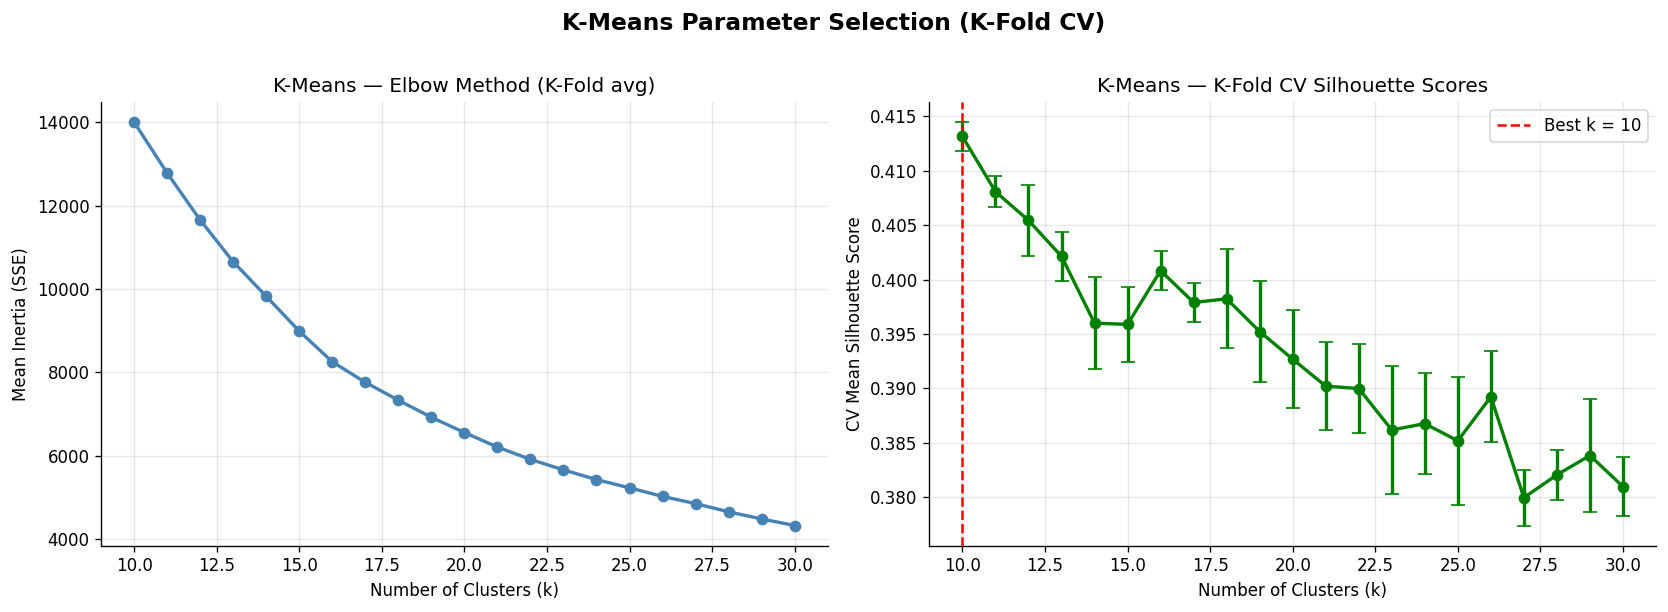

In [12]:
k_vals = list(K_RANGE)
mean_arr = [np.mean(km_cv_scores[k]) for k in k_vals]
std_arr = [np.std(km_cv_scores[k])  for k in k_vals]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(k_vals, [km_inertias[k] for k in k_vals], 'o-', color='steelblue', lw=2)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Mean Inertia (SSE)')
axes[0].set_title('K-Means — Elbow Method (K-Fold avg)')

# CV silhouette plot  
axes[1].errorbar(k_vals, mean_arr, yerr=std_arr, fmt='o-', color='green', lw=2, capsize=4)
axes[1].axvline(best_k, linestyle='--', color='red', label=f'Best k = {best_k}')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('CV Mean Silhouette Score')
axes[1].set_title('K-Means — K-Fold CV Silhouette Scores')
axes[1].legend()

plt.suptitle('K-Means Parameter Selection (K-Fold CV)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [13]:
# Fit final K-Means on full sample with best k
km_final = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
km_labels = km_final.fit_predict(coords_scaled)
df_sample = df_sample.copy()
df_sample['KMeans_Cluster'] = km_labels

# Patrol points set to cluster centroids 
centroids_geo = scaler_spatial.inverse_transform(km_final.cluster_centers_)
centroids_df  = pd.DataFrame(centroids_geo, columns=['Latitude', 'Longitude'])
centroids_df.index.name = 'Patrol Zone'

# Add crime count per zone for prioritization
zone_counts = pd.Series(km_labels).value_counts().sort_index()
centroids_df['Crime Count in Zone'] = zone_counts.values
centroids_df = centroids_df.sort_values('Crime Count in Zone', ascending=False)

print(f'Recommended patrol points ({best_k} zones):')
print(centroids_df.to_string())

Recommended patrol points (10 zones):
              Latitude  Longitude  Crime Count in Zone
Patrol Zone                                           
6            41.880781 -87.710089                16455
2            41.885108 -87.640232                13668
1            41.916411 -87.755788                12909
3            41.775242 -87.663802                12106
8            41.782805 -87.612996                11125
4            41.969612 -87.676427                10468
5            41.700064 -87.632833                 8172
0            41.741119 -87.566485                 7755
9            41.781370 -87.721363                 5829
7            41.972603 -87.841787                 1513


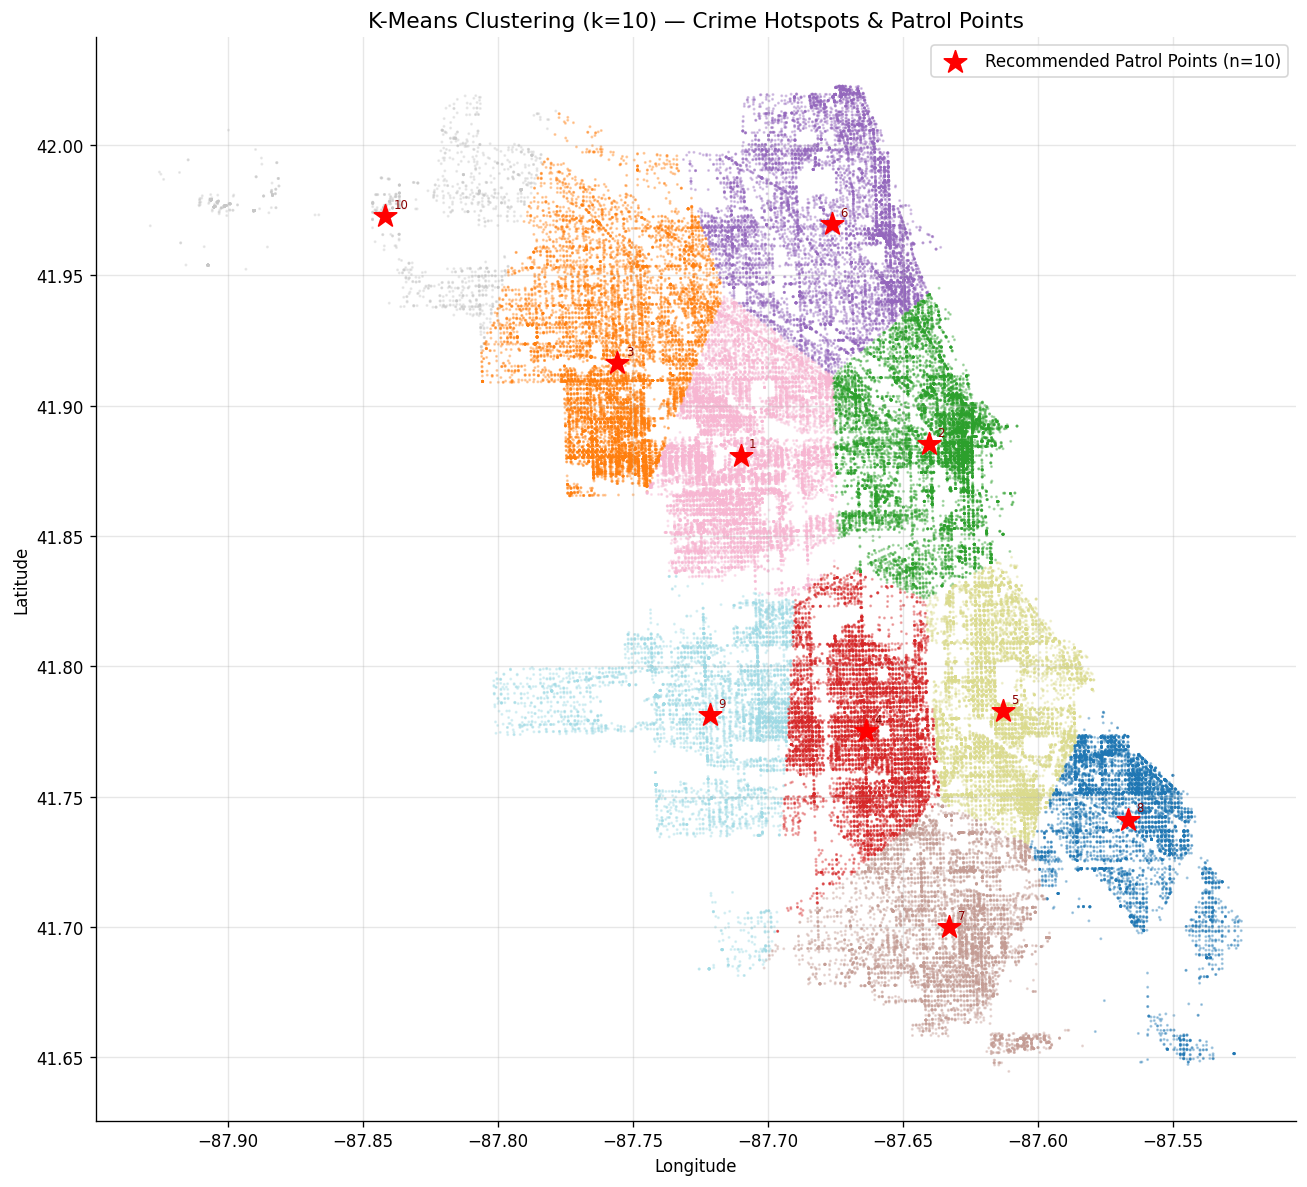

In [14]:
plt.figure(figsize=(11, 10))
scatter = plt.scatter(
    df_sample['Longitude'], df_sample['Latitude'],
    c=km_labels, cmap='tab20', s=0.6, alpha=0.35
)
plt.scatter(
    centroids_df['Longitude'], centroids_df['Latitude'],
    c='red', s=200, marker='*', zorder=5, label=f'Recommended Patrol Points (n={best_k})'
)

# Annotate each patrol point with its zone index
for i, row in centroids_df.reset_index().iterrows():
    plt.annotate(str(i+1), (row['Longitude'], row['Latitude']),
                 textcoords='offset points', xytext=(5, 5), fontsize=7, color='darkred')

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title(f'K-Means Clustering (k={best_k}) — Crime Hotspots & Patrol Points', fontsize=13)
plt.legend(markerscale=1, fontsize=10)
plt.tight_layout()
plt.savefig('kmeans_clusters.png', bbox_inches='tight')
plt.show()

---
## 4. Spatial Clustering — DBSCAN with K-Fold Evaluation

DBSCAN does not require specifying `k` upfront and can find arbitrarily shaped clusters. We use K-Fold to evaluate each `(eps, min_samples)` combination by averaging the silhouette score across folds — consistent with how we evaluated K-Means.

In [15]:
DBSCAN_SAMPLE = 30_000
df_db         = df_sample.sample(n=min(DBSCAN_SAMPLE, len(df_sample)), random_state=RANDOM_STATE)
coords_db_raw = df_db[SPATIAL_FEATURES].dropna().values
coords_db_sc  = scaler_spatial.transform(coords_db_raw)

eps_values         = [0.05, 0.10, 0.15, 0.20]
min_samples_values = [10, 20, 30]

best_sil_db    = -1
best_eps       = None
best_min_s     = None
best_db_labels = None

kf_db = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

print(f'DBSCAN K-Fold CV parameter grid search ({N_SPLITS} folds):')
for eps in eps_values:
    for ms in min_samples_values:
        fold_sils = []
        for train_idx, test_idx in kf_db.split(coords_db_sc):
            X_tr = coords_db_sc[train_idx]
            X_te = coords_db_sc[test_idx]
            db   = DBSCAN(eps=eps, min_samples=ms, n_jobs=-1)
            # DBSCAN fit on train, assign test via nearest-core heuristic
            lbl_tr = db.fit_predict(X_tr)
            n_clusters_tr = len(set(lbl_tr)) - (1 if -1 in lbl_tr else 0)
            if n_clusters_tr < 2:
                continue
            # Score on test split: fit DBSCAN directly on test for silhouette
            db_te  = DBSCAN(eps=eps, min_samples=ms, n_jobs=-1)
            lbl_te = db_te.fit_predict(X_te)
            n_c_te = len(set(lbl_te)) - (1 if -1 in lbl_te else 0)
            if n_c_te < 2:
                continue
            sil = silhouette_score(
                X_te[lbl_te != -1], lbl_te[lbl_te != -1],
                sample_size=min(5000, (lbl_te != -1).sum()), random_state=RANDOM_STATE
            )
            fold_sils.append(sil)

        if not fold_sils:
            print(f'  eps={eps}, min_s={ms:2d} | no valid folds — skip')
            continue

        mean_sil_db = np.mean(fold_sils)
        std_sil_db  = np.std(fold_sils)
        print(f'  eps={eps}, min_s={ms:2d} | mean_sil={mean_sil_db:.4f} ± {std_sil_db:.4f}')

        if mean_sil_db > best_sil_db:
            best_sil_db = mean_sil_db
            best_eps    = eps
            best_min_s  = ms

print(f'\nBest DBSCAN params: eps={best_eps}, min_samples={best_min_s}, CV silhouette={best_sil_db:.4f}')

DBSCAN K-Fold CV parameter grid search (5 folds):
  eps=0.05, min_s=10 | mean_sil=0.2131 ± 0.0556
  eps=0.05, min_s=20 | mean_sil=0.6098 ± 0.0812
  eps=0.05, min_s=30 | mean_sil=0.8175 ± 0.0777
  eps=0.1, min_s=10 | mean_sil=-0.3306 ± 0.0662
  eps=0.1, min_s=20 | mean_sil=-0.1890 ± 0.1418
  eps=0.1, min_s=30 | mean_sil=0.3118 ± 0.0333
  eps=0.15, min_s=10 | mean_sil=-0.0559 ± 0.0438
  eps=0.15, min_s=20 | mean_sil=0.0653 ± 0.0817
  eps=0.15, min_s=30 | mean_sil=-0.2641 ± 0.0000
  eps=0.2, min_s=10 | mean_sil=0.2446 ± 0.0997
  eps=0.2, min_s=20 | mean_sil=0.1461 ± 0.0690
  eps=0.2, min_s=30 | mean_sil=0.2946 ± 0.1756

Best DBSCAN params: eps=0.05, min_samples=30, CV silhouette=0.8175


In [16]:
# Fit final DBSCAN on the full DB sample with best params
db_final       = DBSCAN(eps=best_eps, min_samples=best_min_s, n_jobs=-1)
best_db_labels = db_final.fit_predict(coords_db_sc)

df_db = df_db.copy()
df_db['DBSCAN_Cluster'] = best_db_labels

n_noise       = (best_db_labels == -1).sum()
n_db_clusters = len(set(best_db_labels)) - (1 if -1 in best_db_labels else 0)
print(f'DBSCAN clusters found: {n_db_clusters} | Noise points: {n_noise} ({n_noise/len(best_db_labels)*100:.1f}%)')

# Derive patrol points from DBSCAN cluster centroids
db_centroids = []
for cid in set(best_db_labels):
    if cid == -1:
        continue
    mask  = best_db_labels == cid
    lat_c = coords_db_raw[mask, 0].mean()
    lon_c = coords_db_raw[mask, 1].mean()
    db_centroids.append({'Cluster': cid, 'Latitude': lat_c, 'Longitude': lon_c, 'Crime Count': mask.sum()})

db_centroids_df = pd.DataFrame(db_centroids).sort_values('Crime Count', ascending=False)
print(f'\nTop 15 DBSCAN patrol zones by crime density:')
print(db_centroids_df.head(15).to_string(index=False))

DBSCAN clusters found: 57 | Noise points: 6464 (21.5%)

Top 15 DBSCAN patrol zones by crime density:
 Cluster  Latitude  Longitude  Crime Count
       1 41.774201 -87.636484         5892
       0 41.881166 -87.730649         5562
       2 41.887190 -87.631185         2256
       6 41.754168 -87.569628         1822
       3 41.955606 -87.652937         1201
       9 41.906010 -87.680507          904
       7 41.778813 -87.691392          883
       4 41.690056 -87.627349          746
      11 41.934803 -87.717317          340
      17 41.965660 -87.715546          308
       5 41.879001 -87.680937          270
       8 42.017535 -87.674231          239
      20 42.003573 -87.668199          178
      23 41.810732 -87.701744          175
      29 41.861753 -87.660786          169


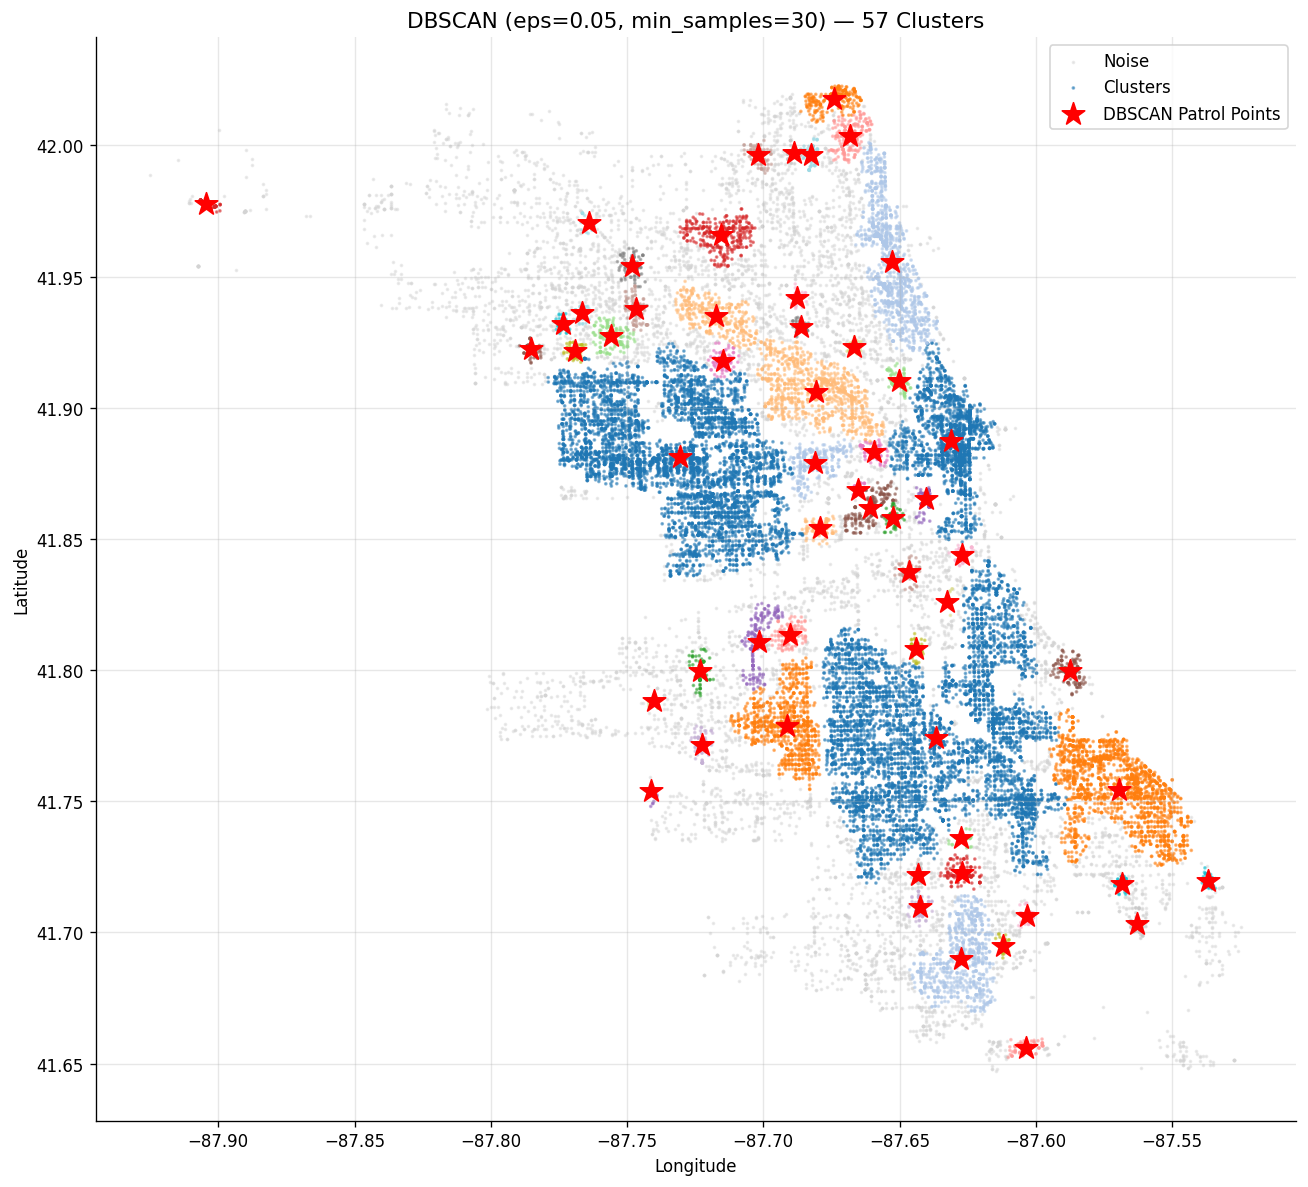

In [30]:
plt.figure(figsize=(11, 10))
mask_noise = best_db_labels == -1
plt.scatter(
    df_db.loc[mask_noise, 'Longitude'], df_db.loc[mask_noise, 'Latitude'],
    c='lightgray', s=1.5, alpha=0.4, label='Noise'
)
plt.scatter(
    df_db.loc[~mask_noise, 'Longitude'], df_db.loc[~mask_noise, 'Latitude'],
    c=best_db_labels[~mask_noise], cmap='tab20', s=1.5, alpha=0.5, label='Clusters'
)
# Mark top 15 DBSCAN patrol points
top_db = db_centroids_df
plt.scatter(
    top_db['Longitude'], top_db['Latitude'],
    c='red', s=200, marker='*', zorder=5, label='DBSCAN Patrol Points'
)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title(f'DBSCAN (eps={best_eps}, min_samples={best_min_s}) — {n_db_clusters} Clusters', fontsize=13)
plt.legend(markerscale=1, fontsize=10)
plt.tight_layout()
plt.savefig('dbscan_clusters.png', bbox_inches='tight')
plt.show()

---
## 5. Clustering Algorithm Comparison

Direct head-to-head comparison of K-Means vs DBSCAN using their best K-Fold CV silhouette scores.

Clustering Algorithm Comparison (K-Fold CV Silhouette):
Algorithm              Best Params  CV Silhouette  Patrol Points                                           Notes
  K-Means                     k=10         0.4132             10       Uniform cluster sizes; requires k upfront
   DBSCAN eps=0.05, min_samples=30         0.8175             57 Handles noise & irregular shapes; k is emergent


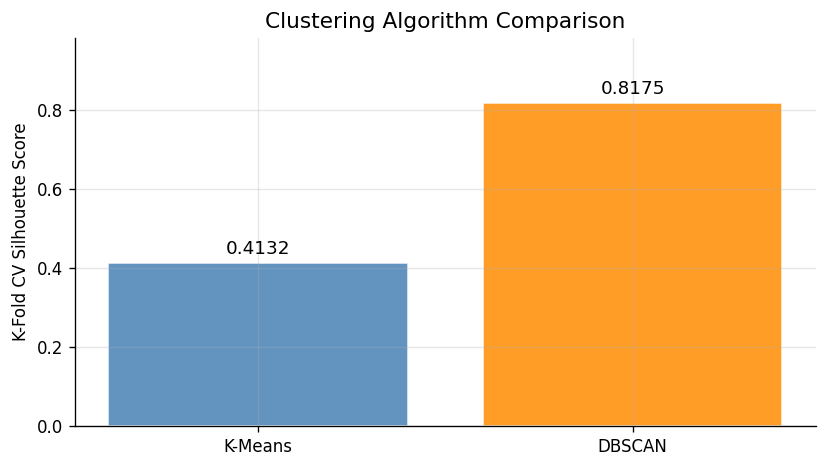


Better-performing algorithm by CV silhouette: DBSCAN


In [31]:
comparison = pd.DataFrame([
    {
        'Algorithm': 'K-Means',
        'Best Params': f'k={best_k}',
        'CV Silhouette': round(mean_sils[best_k], 4),
        'Patrol Points': best_k,
        'Notes': 'Uniform cluster sizes; requires k upfront'
    },
    {
        'Algorithm': 'DBSCAN',
        'Best Params': f'eps={best_eps}, min_samples={best_min_s}',
        'CV Silhouette': round(best_sil_db, 4),
        'Patrol Points': n_db_clusters,
        'Notes': 'Handles noise & irregular shapes; k is emergent'
    }
])

print('Clustering Algorithm Comparison (K-Fold CV Silhouette):')
print(comparison.to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    comparison['Algorithm'],
    comparison['CV Silhouette'],
    color=['steelblue', 'darkorange'], alpha=0.85, edgecolor='white'
)
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=11)
ax.set_ylabel('K-Fold CV Silhouette Score')
ax.set_title('Clustering Algorithm Comparison', fontsize=13)
ax.set_ylim(0, max(comparison['CV Silhouette']) * 1.2)
plt.tight_layout()
plt.savefig('clustering_comparison.png', bbox_inches='tight')
plt.show()

winner = comparison.loc[comparison['CV Silhouette'].idxmax(), 'Algorithm']
print(f'\nBetter-performing algorithm by CV silhouette: {winner}')

---
## 7. Predictive Modeling — Random Forest (High-Risk Zone Prediction)

Rather than predicting crime *type* (which doesn't directly help patrol placement), we train a model to predict whether a spatial grid cell is **high-risk** (above-median crime density). This gives us a forward-looking heat map to recommend proactive patrol placement beyond just historical clustering.

In [21]:
# Align outlier flags back to df_sample and remove outliers
df_clean = df_sample.loc[X_iso.index].copy()
df_clean['IsOutlier'] = iso_preds
df_model = df_clean[df_clean['IsOutlier'] != -1].copy()

# Assign K-Means cluster labels as zone IDs
coords_model = df_model[SPATIAL_FEATURES].dropna().values
coords_model_sc = scaler_spatial.transform(coords_model)
df_model['Zone'] = km_final.predict(coords_model_sc)

# Label zones as high-risk (1) or low-risk (0) based on crime count
zone_crime_counts = df_model['Zone'].value_counts()
median_count      = zone_crime_counts.median()
high_risk_zones   = set(zone_crime_counts[zone_crime_counts >= median_count].index)
df_model['HighRisk'] = df_model['Zone'].apply(lambda z: 1 if z in high_risk_zones else 0)

print(f'High-risk zones: {len(high_risk_zones)} / {best_k}')
print(f'High-risk samples: {df_model["HighRisk"].sum():,} / {len(df_model):,}')

High-risk zones: 5 / 10
High-risk samples: 66,012 / 98,000


In [22]:
model_cols = ['Latitude', 'Longitude', 'Hour', 'DayOfWeek', 'Month', 'IsWeekend', 'Arrest', 'Domestic']
model_cols = [c for c in model_cols if c in df_model.columns]
X_model    = df_model[model_cols].dropna()
y_model    = df_model.loc[X_model.index, 'HighRisk']

X_train, X_test, y_train, y_test = train_test_split(
    X_model, y_model, test_size=0.2, random_state=RANDOM_STATE, stratify=y_model
)

scaler_model = StandardScaler()
X_train_s    = scaler_model.fit_transform(X_train)
X_test_s     = scaler_model.transform(X_test)

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train_s, y_train)
y_pred = rf.predict(X_test_s)
acc    = (y_pred == y_test).mean()

print(f'High-Risk Zone Prediction — Test Accuracy: {acc:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Low Risk', 'High Risk'], zero_division=0))

High-Risk Zone Prediction — Test Accuracy: 0.9870

              precision    recall  f1-score   support

    Low Risk       0.98      0.98      0.98      6398
   High Risk       0.99      0.99      0.99     13202

    accuracy                           0.99     19600
   macro avg       0.99      0.99      0.99     19600
weighted avg       0.99      0.99      0.99     19600



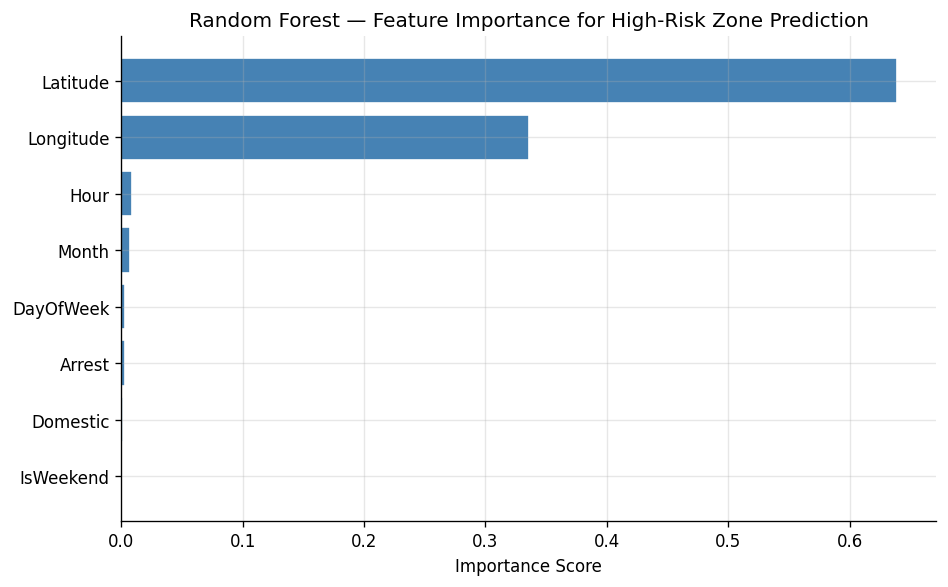

In [23]:
# Feature importance — what drives high-risk zone assignment
feat_imp_df = pd.DataFrame({'Feature': model_cols, 'Importance': rf.feature_importances_})\
    .sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(feat_imp_df['Feature'], feat_imp_df['Importance'], color='steelblue', edgecolor='white')
plt.xlabel('Importance Score')
plt.title('Random Forest — Feature Importance for High-Risk Zone Prediction', fontsize=12)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()

---
## 9. Crime Trend Visualizations

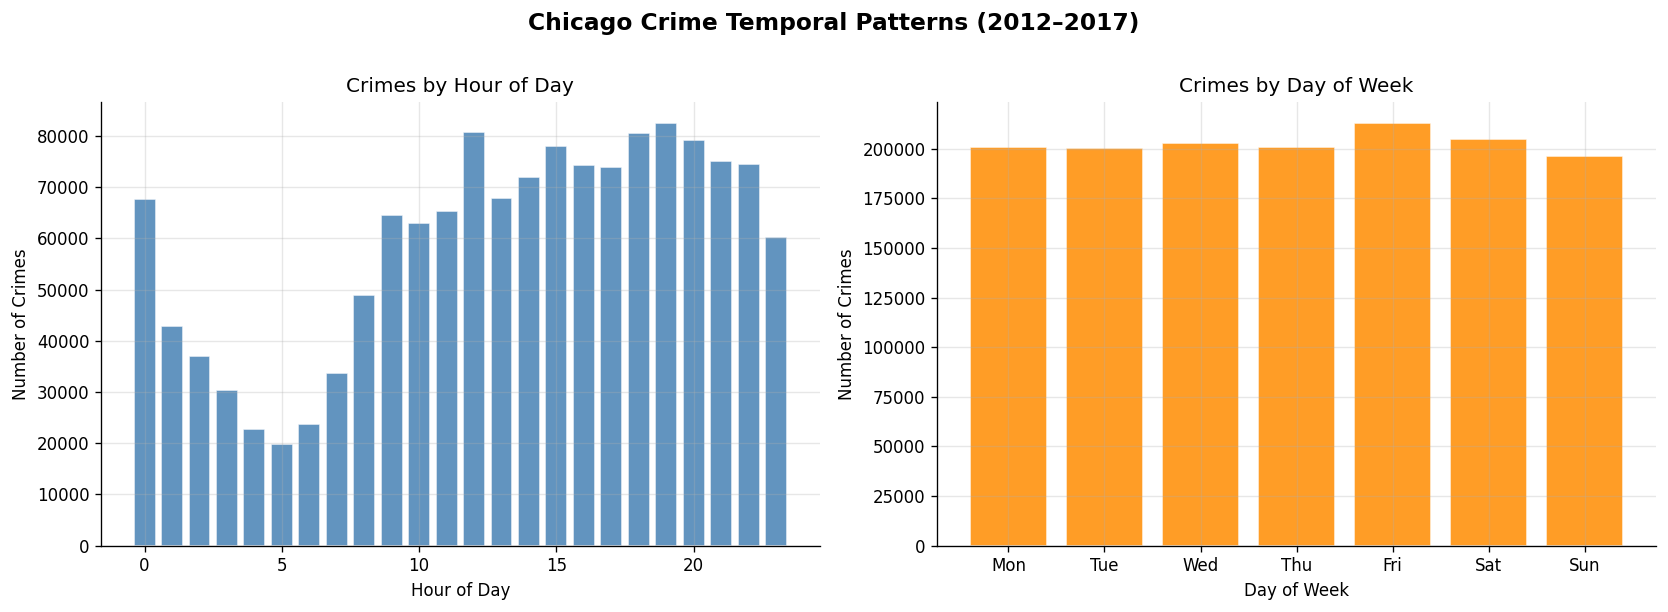

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hour_counts = df['Hour'].value_counts().sort_index()
axes[0].bar(hour_counts.index, hour_counts.values, color='steelblue', alpha=0.85, edgecolor='white')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Number of Crimes')
axes[0].set_title('Crimes by Hour of Day')

dow_labels  = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_counts  = df['DayOfWeek'].value_counts().sort_index()
axes[1].bar(dow_labels, dow_counts.values, color='darkorange', alpha=0.85, edgecolor='white')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Number of Crimes')
axes[1].set_title('Crimes by Day of Week')

plt.suptitle('Chicago Crime Temporal Patterns (2012–2017)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('crime_trends.png', bbox_inches='tight')
plt.show()

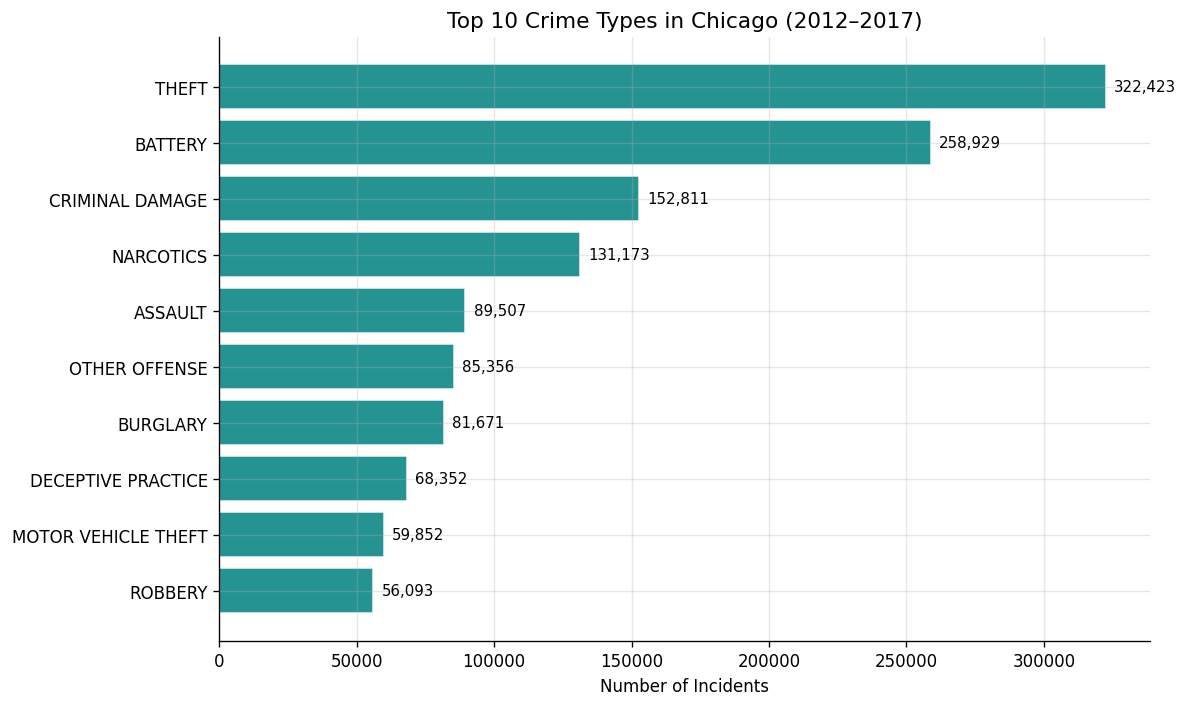

In [27]:
top10 = df['Primary Type'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top10.index[::-1], top10.values[::-1], color='teal', alpha=0.85, edgecolor='white')
ax.bar_label(bars, labels=[f'{v:,}' for v in top10.values[::-1]], padding=5, fontsize=9)
ax.set_xlabel('Number of Incidents')
ax.set_title('Top 10 Crime Types in Chicago (2012–2017)', fontsize=13)
plt.tight_layout()
plt.savefig('top_crimes.png', bbox_inches='tight')
plt.show()